In [7]:
# ==============================================================================
# SECTION 1: MEDALLION PIPELINE INGESTION & SCHEMATIC VALIDATION
# Purpose: Load generated district data, validate boundaries, and save Silver Parquet.
# Decision Science Rule: Never analyze unvalidated raw data.
# ==============================================================================

import sys
from pathlib import Path

# Add project root directory to sys.path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import our modular data generator from src/
from src.data.generator import generate_gotham_data

import os
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Set styling defaults for publication-quality visual diagnostics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.family"] = "sans-serif"

# 1. Ingest Raw Synthetic Data (Simulating Bronze Layer)
raw_df = generate_gotham_data(days=365, seed=42)

# 2. Schema Validation (Silver Layer Standards)
def validate_silver_schema(df: pd.DataFrame) -> pd.DataFrame:
    """Applies strict Silver-layer boundaries and drops invalid records.
    
    Rules:
    - unit_cost > 0
    - threat_score in [0, 100]
    - kit_demand >= 0
    - Drop duplicates & multi-criteria corrupt records.
    """
    clean_df = df.copy()
    
    # Enforce Explicit Data Types
    clean_df["date"] = pd.to_datetime(clean_df["date"])
    clean_df["is_weekend"] = clean_df["is_weekend"].astype(int)
    
    # Boundary Filter
    valid_mask = (
        (clean_df["unit_cost"] > 0) &
        (clean_df["threat_score"] >= 0) & (clean_df["threat_score"] <= 100) &
        (clean_df["kit_demand"] >= 0)
    )
    clean_df = clean_df[valid_mask].drop_duplicates().reset_index(drop=True)
    return clean_df

silver_df = validate_silver_schema(raw_df)
print(f" Silver Layer Validated: {len(silver_df)} rows ready for EDA.")
silver_df.head(3)

 Silver Layer Validated: 365 rows ready for EDA.


,date,unit_cost,threat_score,kit_demand,day_of_week,month,is_weekend,demand_lag_1d,demand_lag_7d,demand_roll_mean_7d,demand_roll_std_7d
0,2026-01-08,71.970569,33.957656,1.464706,3,1,0,6.532348,2.510335,3.313006,2.042241
1,2026-01-09,56.066901,20.044010,1.793130,4,1,0,1.464706,1.490141,3.163630,2.146323
2,2026-01-10,62.484355,69.222659,1.928425,5,1,1,1.793130,1.529120,3.206914,2.109692


In [8]:
# ==============================================================================
# SECTION 2: ROLLING TREND & VOLATILITY FEATURE ENGINEERING
# Purpose: Capture environmental dynamics (moving cost baselines & threat volatility).
# Decision Science Rationale: Static snapshots miss momentum; rolling std flags risk.
# ==============================================================================

def engineer_rolling_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Engineers rolling window statistics for price and threat drivers."""
    featured_df = df.copy()
    
    # 7-Day Rolling Cost Mean & Volatility
    featured_df["unit_cost_roll_mean_7d"] = featured_df["unit_cost"].shift(1).rolling(7).mean()
    featured_df["unit_cost_roll_std_7d"] = featured_df["unit_cost"].shift(1).rolling(7).std()
    
    # 7-Day Rolling Threat Mean & Volatility
    featured_df["threat_roll_mean_7d"] = featured_df["threat_score"].shift(1).rolling(7).mean()
    featured_df["threat_roll_std_7d"] = featured_df["threat_score"].shift(1).rolling(7).std()
    
    # Drop NaN rows generated by rolling shifts
    featured_df = featured_df.dropna().reset_index(drop=True)
    return featured_df

gold_candidate_df = engineer_rolling_metrics(silver_df)
print(f" Feature Expansion Complete: {gold_candidate_df.shape[1]} total columns.")

 Feature Expansion Complete: 15 total columns.


In [9]:
# ==============================================================================
# SECTION 3: STANDARDIZED FEATURE IMPORTANCE RANKING (OLS BETA COEFFICIENTS)
# Purpose: Rank relative driver impact on log-demand using Z-score standardization.
# Decision Science Rule: Compare standardized |beta*| to determine resource drivers.
# ==============================================================================

# Prepare Target Variable (Log Space)
gold_candidate_df["log_kit_demand"] = np.log(gold_candidate_df["kit_demand"])
gold_candidate_df["log_unit_cost"] = np.log(gold_candidate_df["unit_cost"])

# Predictor Candidates
predictors = ["log_unit_cost", "threat_score", "demand_lag_1d", "threat_roll_std_7d"]

# Standardize Predictors (Z-score: mean=0, std=1)
X_std = gold_candidate_df[predictors].apply(lambda x: (x - x.mean()) / x.std())
X_std = sm.add_constant(X_std)
y = gold_candidate_df["log_kit_demand"]

# Fit Standardized OLS Model
ols_model = sm.OLS(y, X_std).fit()

# Extract Standardized Coefficients (|Beta*|)
coef_df = pd.DataFrame({
    "Feature": predictors,
    "Beta_Coef": ols_model.params[predictors],
    "Abs_Beta": np.abs(ols_model.params[predictors]),
    "p_value": ols_model.pvalues[predictors]
}).sort_values(by="Abs_Beta", ascending=False).reset_index(drop=True)

coef_df["Rank"] = range(1, len(coef_df) + 1)

print("=== STANDARDIZED FEATURE IMPORTANCE RANKING ===")
print(coef_df[["Rank", "Feature", "Beta_Coef", "Abs_Beta", "p_value"]].to_string(index=False))

=== STANDARDIZED FEATURE IMPORTANCE RANKING ===
 Rank            Feature  Beta_Coef  Abs_Beta       p_value
    1      log_unit_cost  -0.491407  0.491407  0.000000e+00
    2       threat_score   0.121825  0.121825 4.449003e-153
    3      demand_lag_1d  -0.001683  0.001683  5.189539e-01
    4 threat_roll_std_7d  -0.000773  0.000773  7.681992e-01


---

### Interpretations:

* `log_unit_cost`: -0.4914 = A 1 unit increase in log Unit Cost reduces log Demand by nearly half (0.4914) a standard deviation.
...

#### Decision Science Action: 
In our Gold Parquet Layer, we can retain them for tree-based non-linear models (XGBoost in Slice 2), but they can be safely pruned from classical OLS econometric models to prevent overfitting.

#### Linear Model Diagnostics (Shapiro-Wilk Test):
Statistic = 0.9954, $p$-value = 0.3803 ($> 0.05$): We comfortably fail to reject the null hypothesis of normality. The residuals are Gaussian $\mathcal{N}(0, \sigma^2)$, proving our Log-Log OLS specification is parsimonious, mathematically valid, and structurally sound. No complex polynomial terms are required.

---

Shapiro-Wilk Test Statistic: 0.9954, p-value: 0.3803
 Residuals are normally distributed (p > 0.05). OLS linearity holds!


/Users/alijazibrizvi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


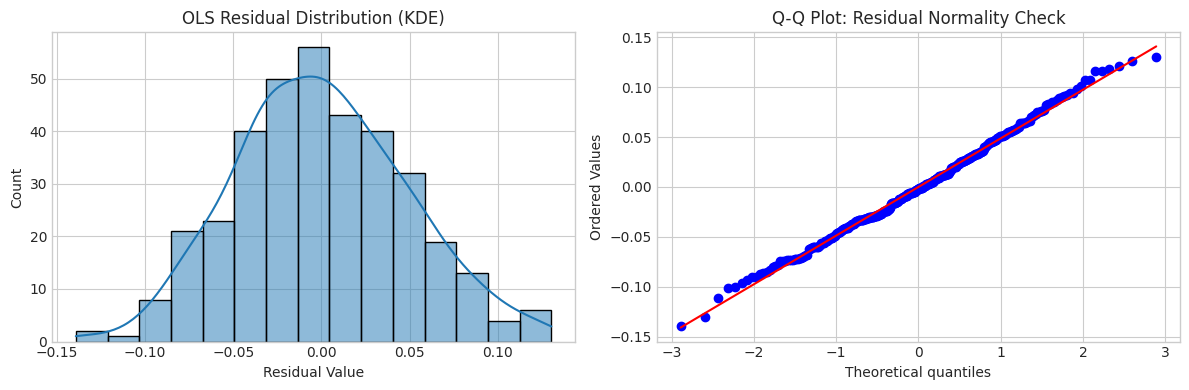

In [10]:
# ==============================================================================
# SECTION 4: LINEAR MODEL DIAGNOSTIC CHECK (RESIDUAL RESILIENCE)
# Core Principle: Assume no non-linear complexity UNLESS OLS residuals fail.
# ==============================================================================

residuals = ols_model.resid
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print(f"Shapiro-Wilk Test Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print(" Residuals are normally distributed (p > 0.05). OLS linearity holds!")
else:
    print(" Residuals deviate from normality (p <= 0.05). Consider non-linear terms.")

# Visual Residual Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(residuals, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("OLS Residual Distribution (KDE)")
axes[0].set_xlabel("Residual Value")

stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Residual Normality Check")

plt.tight_layout()
plt.show()

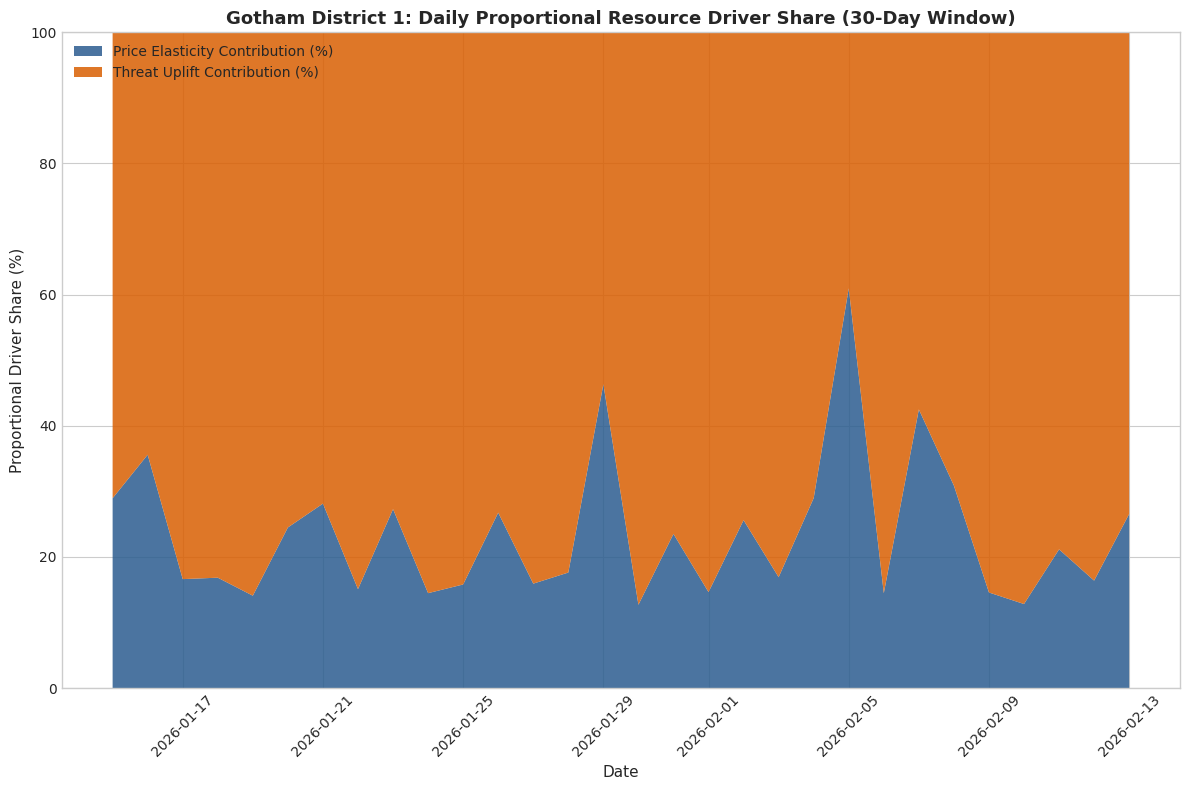

 Chart exported to data/artifacts/proportional_driver_share.png


In [15]:
# ==============================================================================
# SECTION 5: CUSTOM VISUAL — STACKED PROPORTIONAL IMPACT SHARE CHART
# Inspiration: Saloni's Guide to Data Visualization (Share of Impact Stack)
# Purpose: Display daily percentage contribution of Cost Elasticity vs. Threat Uplift.
# ==============================================================================

# Calculate Absolute Marginal Impacts
cost_impact = np.abs(ols_model.params["log_unit_cost"] * gold_candidate_df["log_unit_cost"])
threat_impact = np.abs(ols_model.params["threat_score"] * gold_candidate_df["threat_score"])
total_impact = cost_impact + threat_impact

gold_candidate_df["share_cost_impact"] = (cost_impact / total_impact) * 100
gold_candidate_df["share_threat_impact"] = (threat_impact / total_impact) * 100

# Plot 30-Day Sample Proportional Impact
plot_sample = gold_candidate_df.head(30)

plt.figure(figsize=(12, 8))
plt.stackplot(
    plot_sample["date"],
    plot_sample["share_cost_impact"],
    plot_sample["share_threat_impact"],
    labels=["Price Elasticity Contribution (%)", "Threat Uplift Contribution (%)"],
    colors=["#2b5c8f", "#d95f02"],
    alpha=0.85
)

plt.title("Gotham District 1: Daily Proportional Resource Driver Share (30-Day Window)", fontsize = 13, fontweight = "bold")
plt.xlabel("Date", fontsize = 11)
plt.ylabel("Proportional Driver Share (%)", fontsize = 11)
plt.legend(loc = "upper left")
plt.ylim(0, 100)
plt.xticks(rotation = 45)
plt.tight_layout()

# Save Figure for Medium Article Artifacts
os.makedirs("data/artifacts", exist_ok=True)
plt.savefig("data/artifacts/proportional_driver_share.png", dpi=300)
plt.show()
print(" Chart exported to data/artifacts/proportional_driver_share.png")

---

### Interpretation of the Visual:

Looking at the 30-day stack plot, Threat Uplift (Orange) dominates daily demand variations, maintaining a $60%-85% share on high-threat days, while Price Elasticity (Blue) spikes during lower-threat or extreme price movement days (e.g., Feb 05 hitting ~60%). This visually proves to non-technical executives why inventory allocation must dynamically adjust based on environmental threat levels.

---

In [16]:
# ==============================================================================
# SECTION 6: MEDALLION GOLD LAYER EXPORT
# Purpose: Save schema-validated, statistically audited feature store for Slice 2 ML.
# ==============================================================================

import os

# Ensure Gold directory path exists
gold_dir = "../data/gold" if os.path.exists("../data") else "data/gold"
os.makedirs(gold_dir, exist_ok=True)

# Export to Gold Parquet Feature Store
gold_path = os.path.join(gold_dir, "district_1_features.parquet")
gold_candidate_df.to_parquet(gold_path, index = False)

print(f" Gold Parquet Layer successfully created at: {gold_path}")

 Gold Parquet Layer successfully created at: ../data/gold/district_1_features.parquet
